In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\D\New folder\ieee\week10 (seaborn)\task9\data\mymoviedb.csv",engine="python")
df

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
...,...,...,...,...,...,...,...,...,...
9832,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9833,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9834,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...


In [31]:
print(df.shape)
df.info()

(9826, 9)
<class 'pandas.DataFrame'>
Index: 9826 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9826 non-null   datetime64[us]
 1   Title              9826 non-null   str           
 2   Overview           9826 non-null   str           
 3   Popularity         9826 non-null   float64       
 4   Vote_Count         9826 non-null   str           
 5   Avg_Rating         9826 non-null   float64       
 6   Original_Language  9826 non-null   str           
 7   Genre              9826 non-null   str           
 8   Poster_Url         9826 non-null   str           
dtypes: datetime64[us](1), float64(2), str(6)
memory usage: 767.7 KB


In [4]:
df.dropna(inplace=True)


In [5]:
df.rename(columns={'Vote_Average': 'Avg_Rating'},inplace=True)

In [4]:
genre_series = df['Genre']
from collections import Counter 
genre_counter = Counter()
genres=[]
count=[]

In [6]:
for genre in genre_series :
    genre_counter.update(genre.split(", "))
genre_counter    

Counter({'Drama': 3744,
         'Comedy': 3031,
         'Action': 2686,
         'Thriller': 2488,
         'Adventure': 1853,
         'Romance': 1476,
         'Horror': 1470,
         'Animation': 1438,
         'Family': 1414,
         'Fantasy': 1308,
         'Science Fiction': 1273,
         'Crime': 1242,
         'Mystery': 773,
         'History': 427,
         'War': 308,
         'Music': 295,
         'Documentary': 215,
         'TV Movie': 214,
         'Western': 137})

In [7]:
for x in genre_counter.most_common(20):
    genres.append(x[0])
    count.append(x[1])


Text(0, 0.5, 'Genre')

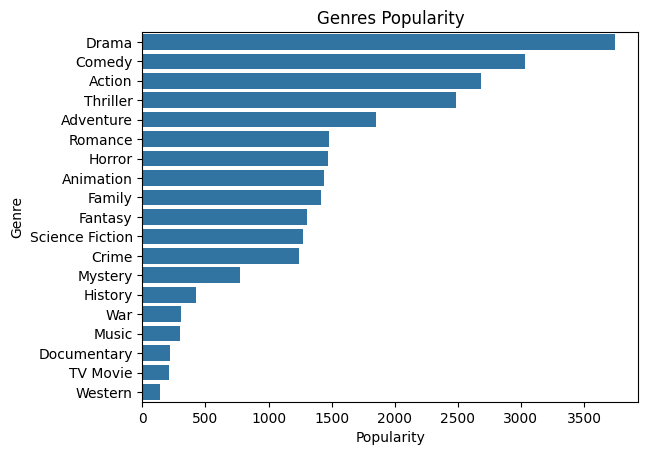

In [ ]:
sns.barplot(y= genres,x= count)
plt.title('Genres Popularity')
plt.xlabel("Popularity")
plt.ylabel("Genre")

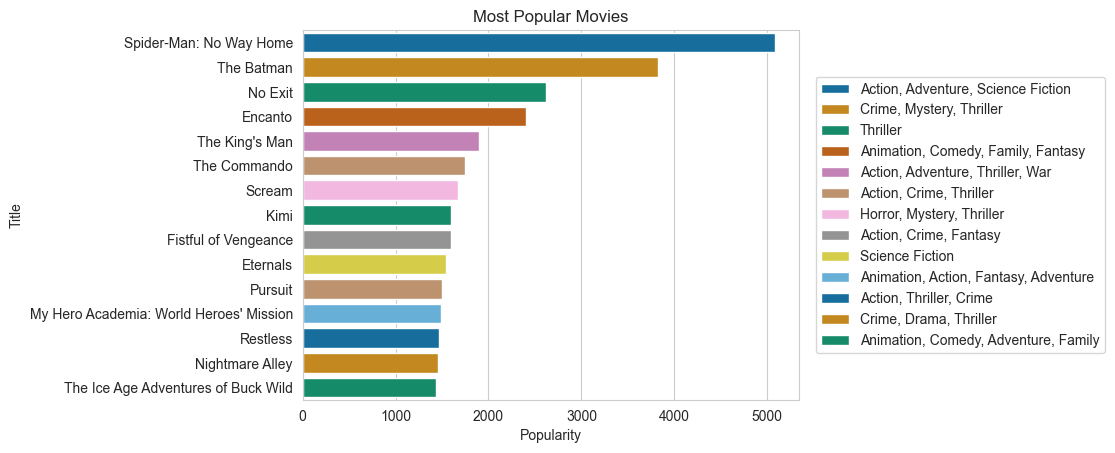

In [39]:
sns.barplot(data=(df.head(15)),y='Title' ,x= "Popularity",hue='Genre',palette='colorblind')
plt.title('Most Popular Movies')
plt.xlabel("Popularity")
plt.ylabel("Title")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.show()


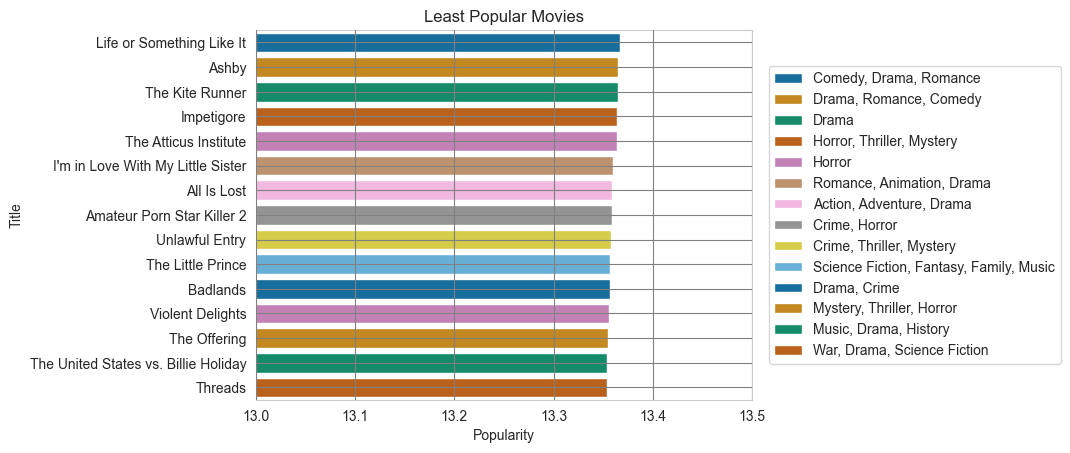

In [43]:
ax= sns.barplot(data=(df.tail(15)),y='Title' ,x= "Popularity",hue='Genre',palette='colorblind')
ax.set_axisbelow(False)
ax.grid(True, color="gray")
plt.title('Least Popular Movies')
plt.xlabel("Popularity")
plt.ylabel("Title")
plt.xlim(13, 13.5)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.show()

In [13]:
df['Release_Date']= pd.to_datetime(df['Release_Date'])

Text(0.5, 1.0, 'Number of Movies by Year')

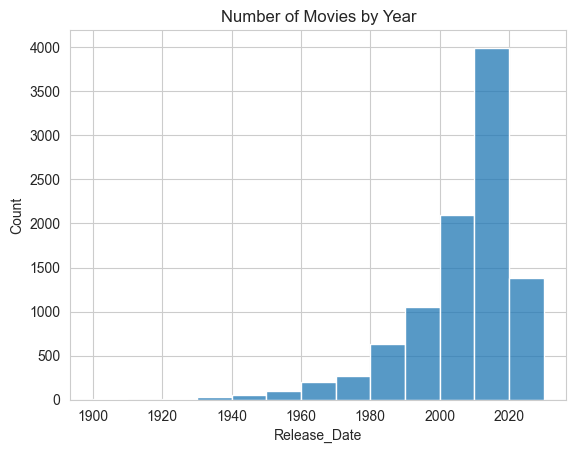

In [29]:
sns.set_style('whitegrid')
sns.histplot(data= df,x= df['Release_Date'].dt.year,bins=[1900,1910,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010,2020,2030])
plt.title("Number of Movies by Year")

In [19]:
df['Avg_Rating']= pd.to_numeric(df['Avg_Rating'])
df['Vote_Count']= pd.to_numeric(df['Vote_Count'])
highest_rated = df.nlargest(50,'Avg_Rating')

In [20]:
highest_rated['Vote_Count'] = pd.to_numeric(highest_rated['Vote_Count'])
highest_rated = highest_rated[~(highest_rated["Vote_Count"] < 1000)]

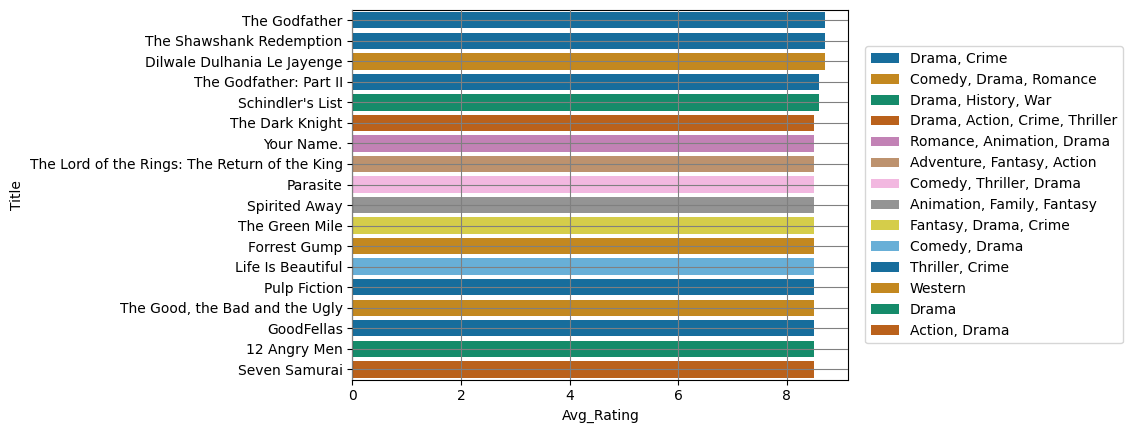

In [10]:
ax2=sns.barplot(data= highest_rated ,x= 'Avg_Rating' ,y='Title', hue='Genre',palette='colorblind')
ax2.set_axisbelow(False)
ax2.grid(True, color="gray")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

Text(0.5, 1.0, 'Correlation')

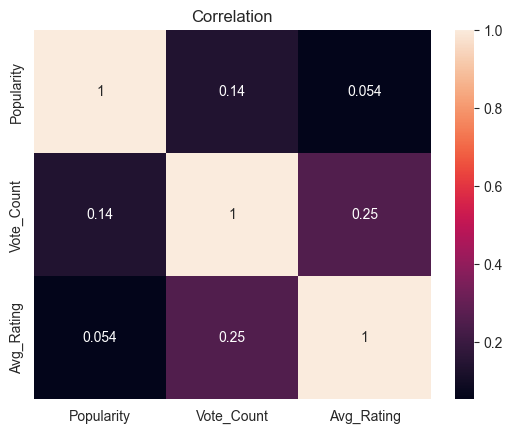

In [25]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation")